# Продвинутый Python, Лекция 3

**Лектор:** Садуллаев Музаффар

**Семинаристы:** Бобоев Мурод, Богданов Сергей, Васина Олеся, Дергачев Cтепан, Какурин Василий, Садуллаев Музаффар, Солодовников Михаил

**In our heart**: Петров Тимур

**Spoiler Alert:** в рамках курса нельзя изучить ни одну из тем от и до досконально (к сожалению, на это требуется больше времени, чем даже 3 часа в неделю). Но мы попробуем рассказать столько, сколько возможно :)

Сегодня говорим про тестирование и логгирование (на примере TDD)

Любая программа, которую вы делаете, надо тестировать. К сожалению, в реальной жизни у вас нет сразу тестов, так что и писать их приходится самостоятельно

# Тестирование

### Паттерн разработки TDD

TDD - test-driven developement или разработка через тестирование. Достигается соблюдением трех правил.

**Три правила TDD**:

 - Продакшн-код можно писать только для починки падающего теста
 - В тесте нужно писать ровно столько кода, сколько необходимо чтобы он упал. Ошибки компиляции считаются падениями теста.
 - В прод можно написать ровно столько кода, сколько требуется для починки дного падающего теста.


 Получается следйющий пайплайн - пишем падающий тест, пишем код чтобы тест не падал, рефакторим код так, чтобы тесты не падали. Повторяем до сходимости.

1. [Test Driven Development: By Example 1st Edition](https://www.eecs.yorku.ca/course_archive/2003-04/W/3311/sectionM/case_studies/money/KentBeck_TDD_byexample.pdf)
2. [On Growing Object Oriented Software, Guided by Tests](https://www.amazon.com/Growing-Object-Oriented-Software-Guided-Tests/dp/0321503627)


### Каты

![](https://karate.by/uploads/posts/2010-10/kkk0001s.png)

Каты - упражнения по программированию, помогающие отточить навыки путем многократного повторнеия. Концепция взята из японских боевых искусств. Подробнее про них можно почитать в книжке [The Pragmatic Programmer](https://pragprog.com/titles/tpp20/the-pragmatic-programmer-20th-anniversary-edition/)



**Ката Greeter**

Данную кату надо выполнять строго по пунктам, не заглядывая вперед:

- Создайте класс `Greeter`, у которого есть метод `greet` принимающий на вход имя и возвращающий "Hello <имя>".
- Метод `greet` должен убирать лишние пробелы - в начале и в конце имени
- Метод `greet` должен возвращать ошибку если имя - пустая строка (или строка с пробелами)
- Метод `greet` возвращает "Good evening <имя>" если текущее время - 18:00-22:59

### Набор утверждений

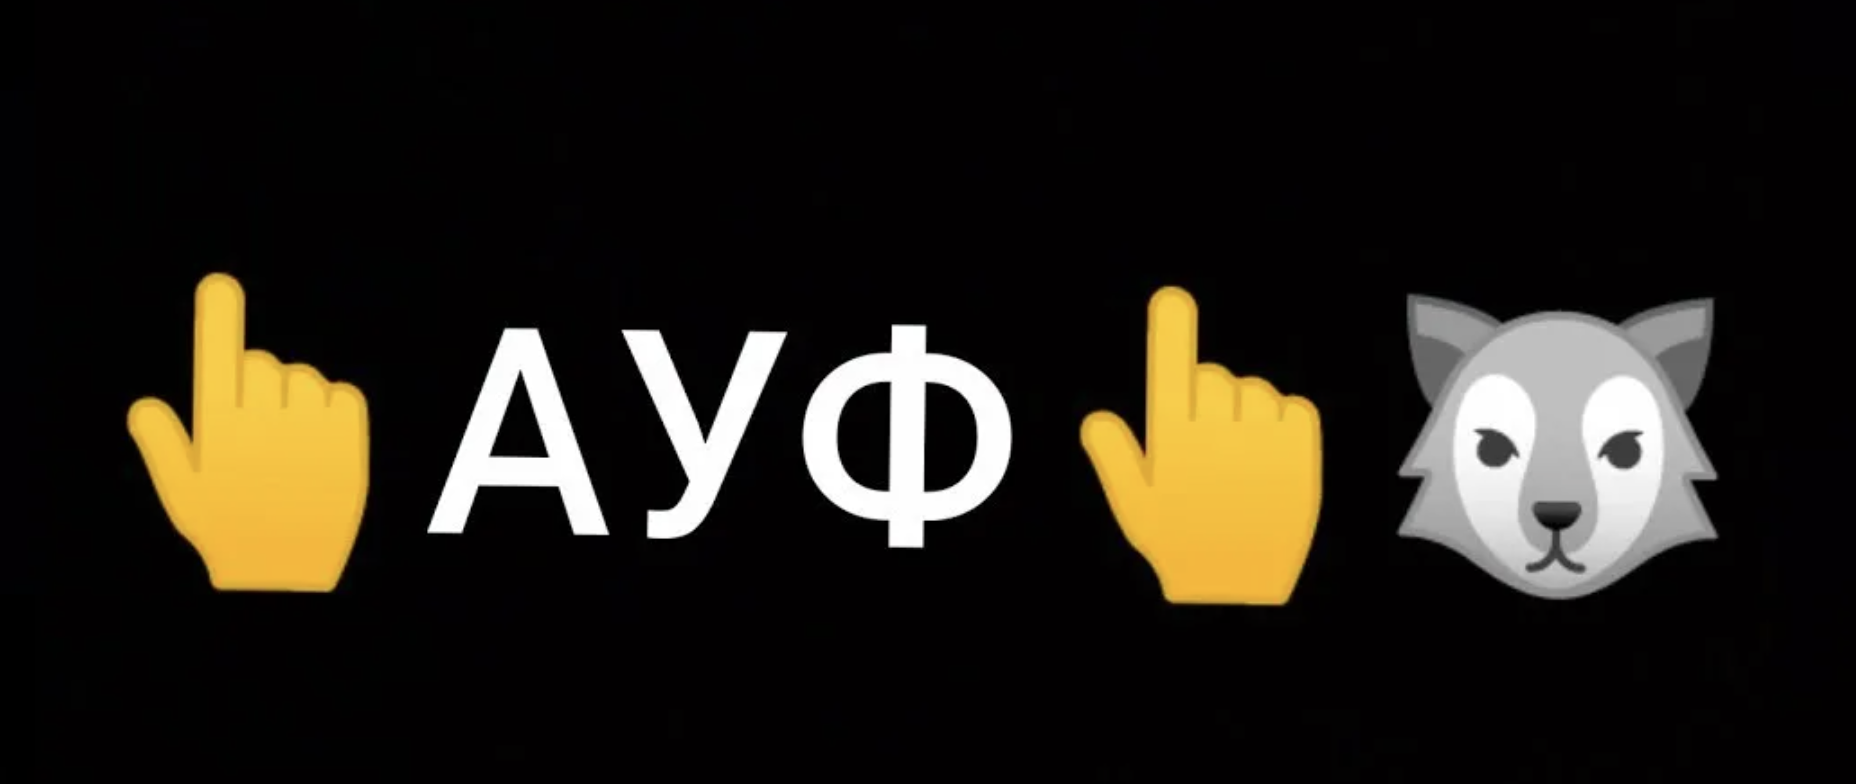

#### Тестов много не бывает

#### Много тестов -- не всегда хорошо

#### Один хороший тест лучше 100 плохих (cправедливо)

На подумать: что значит хороший тест? Покрытие? Репутация? Думайте. Ладно, вернемся тут в конце.

## Архитектура pytest

### Что происходит когда запускается pytest

```shell
python -m pytest .

```

1. Вызывается `__main__.py` который принимает то что вы ему указали (в нашем примере мы указали просто путь тестов без излишеств)
2. Создается объект `Session`

### Session

Сессия = один запуск pytest

* все найденные тесты (вложенные модули, классы, функции)
* конфигурацию запуска (аргументы, ini-файлы)
* отчет о запуске:

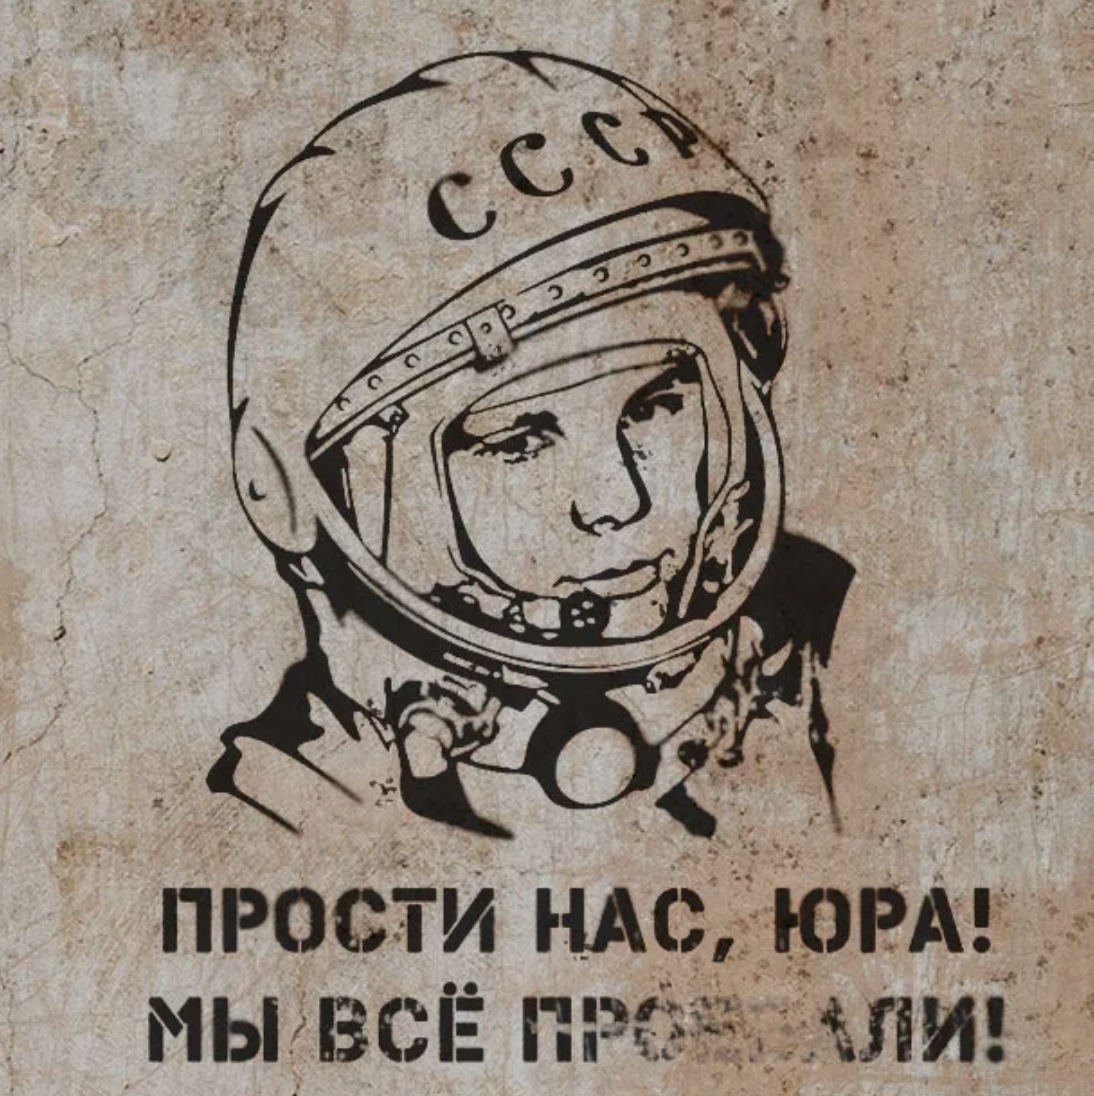

### А что дальше?

А дальше pytest начинает обход файловой системы (то что мы указали в аргументах).

Для каждого файла `test_*.py` он:
* импортирует такие файлы как питонячий-модуль
* создаёт узел `Module` и вешает его на `Session`
* как только он создал узел модуль он заходит в него и ищет тестовые функции и классы. Функция как мы и говорили начинаться должна  `def test_name_of_test()`, а класс `class TestNameOfClass()`
* после этого для классов он в этом же дереве строит узел `Class` а для функций `FunctionDefenition`

### FunctionDefenition

Минимальный объект внутреннего дерева `pytest`, который представляет тестовую функцию. Описание теста. Просто описывает его:

- ссылку на оригинальную Python-функцию (`def test_...`)
- информацию о местоположении (файл, строка, имя),
- маркеры (`@pytest.mark.parametrize`, `@pytest.mark.skip` и т.п.)
- список аргументов, которые нужно разрешить через фикстуры или параметризацию.

### А что по итогу?

```
Session
│
├── Module(test_math.py)
│   ├── FunctionDefinition(test_add[1-2-3])
│   ├── FunctionDefinition(test_add[2-2-4])
│   └── Class(TestMul)
│       └── FunctionDefinition(test_mul)
│
└── Module(test_other.py)
    └── FunctionDefinition(test_sub)
```

## Первый тест

Для автоматизированного тестирования написано много фреймворков на разных языках. Короткий список для python:

* [unittest](https://docs.python.org/3/library/unittest.html)
* [nose2](https://docs.nose2.io/en/latest/)
* [pytest](https://docs.pytest.org/en/latest/)

В рамках лекции мы остановимся на `pytest`. Почему он? Банально - он удобнее (если детально углубляться, глобально инчем не отличаются, просто в pytest уже достаточно много всего сделано из коробки)

In [3]:
!python3 -m pip install ipytest pytest coverage

  Using cached ipytest-0.14.2-py3-none-any.whl.metadata (17 kB)
  Using cached pytest-8.4.2-py3-none-any.whl.metadata (7.7 kB)
  Using cached coverage-7.10.6-cp313-cp313-macosx_11_0_arm64.whl.metadata (8.9 kB)
  Using cached iniconfig-2.1.0-py3-none-any.whl.metadata (2.7 kB)
  Using cached pluggy-1.6.0-py3-none-any.whl.metadata (4.8 kB)
Using cached ipytest-0.14.2-py3-none-any.whl (18 kB)
Using cached pytest-8.4.2-py3-none-any.whl (365 kB)
Using cached pluggy-1.6.0-py3-none-any.whl (20 kB)
Using cached coverage-7.10.6-cp313-cp313-macosx_11_0_arm64.whl (217 kB)
Using cached iniconfig-2.1.0-py3-none-any.whl (6.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [ipytest]m3/5 [pytest]


In [4]:
import pytest
import ipytest
import coverage
ipytest.autoconfig()
__file__ = "testing_and_logging_lection.ipynb"

#### Как pytest находит тесты:

1. Рекурсивно находит все python-файлы в текущей директории
2. Оставляет только файлы вида `test_*.py` и `*_test.py`
3. В этих файлах
  1. Находит все функции с префиксом `test`
  2. Находит все методв с префиксом `test` внутри классов с префиксом `Test`. У классов не должно быть метода `__init__`
  
Поведение можно модифицировать. [Подробнее в документации](https://docs.pytest.org/en/stable/goodpractices.html#test-discovery)

Напишем минимальный тест (который, естественно, упадет)

In [5]:
%%ipytest -q
def test_greeter():
    Greeter()

F                                                                                            [100%]
============================================= FAILURES =============================================
___________________________________________ test_greeter ___________________________________________

    def test_greeter():
>       Greeter()
        ^^^^^^^
E       NameError: name 'Greeter' is not defined

/var/folders/1k/s7xycc896gd2kbcgp89z21_06b4zqs/T/ipykernel_49773/2509433668.py:2: NameError
===================================== short test summary info ======================================
FAILED t_254c859127484b2ca3c786663de05c65.py::test_greeter - NameError: name 'Greeter' is not defined


`pytest` выводит отчет, в котором можно посмотреть сколько у нас всего тестов, какие из них упали и по какой причине.

Теперь сделаем так чтобы тест проходил

TDD выглядит следующим образом:

1. Написали тест

2. Написали кусок кода

3. Проверили, что проходит тест

4. PROFIT

In [6]:
class Greeter:
    pass

In [7]:
%%ipytest -q
def test_greeter():
    assert Greeter()

.                                                                                            [100%]


Сначала мы пишем тесты на реализацию что должно проверять, а только потом делаем реализацию.

Теперь наконец-то напишем нормальный тест, воспользовавшись основной фишкой `Pytest` - `assert`. `Pytest` находит все вызовы `assert` в коде тестов, а затем переписывает этот код так, чтобы в случае падения пользователь мог получить удобный дифф и трейсбек.

- [Демки разных ассертов](https://docs.pytest.org/en/stable/example/reportingdemo.html#tbreportdemo)
- [Цикл статей про то, как это работает](https://www.pythoninsight.com/2018/01/assertion-rewriting-in-pytest-part-1/)

Базово assert работает достаточно просто: мы вызываем некоторое выражение, которое должно выдавать True/False. Получилось True - мы молодцы, False - нет, роняем

In [8]:
%%ipytest -q
def test_greeter():
    name = "Mike"
    assert Greeter().greet(name) == name

F                                                                                            [100%]
============================================= FAILURES =============================================
___________________________________________ test_greeter ___________________________________________

    def test_greeter():
        name = "Mike"
>       assert Greeter().greet(name) == name
               ^^^^^^^^^^^^^^^
E       AttributeError: 'Greeter' object has no attribute 'greet'

/var/folders/1k/s7xycc896gd2kbcgp89z21_06b4zqs/T/ipykernel_49773/3060489621.py:3: AttributeError
===================================== short test summary info ======================================
FAILED t_254c859127484b2ca3c786663de05c65.py::test_greeter - AttributeError: 'Greeter' object has no attribute 'greet'


Еще одна итерация TDD:

In [9]:
class Greeter:
    def greet(self, name):
        return name

In [10]:
%%ipytest -q
def test_greeter():
    name = "Mike"
    assert Greeter().greet(name) == name

.                                                                                            [100%]


#  Параметризация

Наша реализация представляет собой немного не то что мы хотели. В чем проблема? А в том, что у нас написан всего 1 тест, который можно обработать изощренно:

In [11]:
class Greeter:
    def greet(self, name):
        return "Mike"

In [12]:
%%ipytest -q
def test_greeter():
    name = "Mike"
    assert Greeter().greet(name) == name

.                                                                                            [100%]


Наверное стоит добавить больше разных тестов, чтобы вводы были разные.

Чтобы не копировать один и тот же тест (и не плодить 100500 тестов), можно воспользоваться параметризацией:

Посмотрим что это такое на примере:

In [13]:
%%ipytest -q
import pytest


@pytest.mark.parametrize("a, b, c", [
    (1, 2, 3),
    (3, 4, 7),
    (5, 6, 11),
])
def test_sample_parametrization(a, b, c):
    assert a + b == c

...                                                                                          [100%]


### Что вообще произошло и что это такое

Буквально 

```python
@pytest.mark.parametrize("a, b, c", [
    (1, 2, 3),
    (3, 4, 7),
    (5, 6, 11),
])
```

```python

for (a, b, c) in [(1,2,3), (3,4,7), (5,6,11)]:
    test_sample_parametrization(a, b, c)
```


Давайте рассмотрим что из себя оно представляет:

Конкректно у нас фигурирует тут: `pytest.mark.parametrize`
Декоратор, который позволяет параметризировать (использовать несколько наборов данных) на тестовую функцию.

Каждая комбинация значений будет автоматически передаваться в тестовую функцию и pytest выполнит для каждого набора тестовых данных.



```python
@pytest.mark.parametrize("<аргумент1>, <аргумент2>, <аргумент3>, ...", [<набор_Значений_для_аргумента_1>, <набор_значений_для_аргумента_2>, <набор_значений_для_аргумента_3>, ...]
ИЛИ [
    (<набор_Значений_для_аргумента_1>, <набор_значений_для_аргумента_2>, <набор_значений_для_аргумента_3>, ...),
    (<набор_Значений_для_аргумента_1>, <набор_значений_для_аргумента_2>, <набор_значений_для_аргумента_3>, ...),
    (<набор_Значений_для_аргумента_1>, <набор_значений_для_аргумента_2>, <набор_значений_для_аргумента_3>, ...)
])
def test_<название теста>(<аргумент1>, <аргумент2>, <аргумент3>, ...):

    <подготовка или демонстрация тестового сценария>

    assert <проверяемое выражение>

```


* аргументы в фикстурах -- переменные и для каждой переменной должно быть значение типа object (то есть любой объект)

Если не будет хоть одного значения тест завершится ошибкой с проверкой на количество аргументов и значений  `assert len(param.values) != len(argnames)`

In [14]:
%%ipytest -q

@pytest.mark.parametrize("a, b, c", [1, 2])
def test_sample(a, b, c):
    assert a + b == 3


============================================== ERRORS ==============================================
______________________ ERROR collecting t_254c859127484b2ca3c786663de05c65.py ______________________
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pluggy/_hooks.py:512: in __call__
    return self._hookexec(self.name, self._hookimpls.copy(), kwargs, firstresult)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pluggy/_manager.py:120: in _hookexec
    return self._inner_hookexec(hook_name, methods, kwargs, firstresult)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/_pytest/python.py:240: in pytest_pycollect_makeitem
    return list(collector._genfunctions(name, obj))
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
/Library/Frameworks/

Видим отчеты пайтеста во всей красе. Починим тесты:

In [15]:
%%ipytest -q
test_cases = [("Mike", "Hello Mike"), ("John", "Hello John"), ("Greg", "Hello Greg")]

@pytest.mark.parametrize("name, greeting", test_cases)
def test_greeter(name, greeting):
    assert Greeter().greet(name) == greeting

FFF                                                                                          [100%]
============================================= FAILURES =============================================
__________________________________ test_greeter[Mike-Hello Mike] ___________________________________

name = 'Mike', greeting = 'Hello Mike'

    @pytest.mark.parametrize("name, greeting", test_cases)
    def test_greeter(name, greeting):
>       assert Greeter().greet(name) == greeting
E       AssertionError: assert 'Mike' == 'Hello Mike'
E         
E         - Hello Mike
E         + Mike

/var/folders/1k/s7xycc896gd2kbcgp89z21_06b4zqs/T/ipykernel_49773/2110350598.py:5: AssertionError
__________________________________ test_greeter[John-Hello John] ___________________________________

name = 'John', greeting = 'Hello John'

    @pytest.mark.parametrize("name, greeting", test_cases)
    def test_greeter(name, greeting):
>       assert Greeter().greet(name) == greeting
E       AssertionErr

In [16]:
class Greeter:
    def greet(self, name):
        return "Hello " + name

In [17]:
%%ipytest -q
test_cases = [("Mike", "Hello Mike"), ("John", "Hello John"), ("Greg", "Hello Greg")]

@pytest.mark.parametrize("name, greeting", test_cases)
def test_greeter(name, greeting):
    assert Greeter().greet(name) == greeting

...                                                                                          [100%]


Ура, мы выполнили первый пункт!

Перейдем к следующему пункту нашего задания:

- Метод `greet` должен убирать лишние пробелы - в начале и в конце имени

Опять же, напишем тест:

In [18]:
%%ipytest -q

def test_spaces():
    greeter = Greeter()
    greeting = greeter.greet(" Mike")
    assert not greeting.startswith(" ")

.                                                                                            [100%]


Обратим внимание что тест проходит и возникает соблазн продолжить работу. Однако если посмотреть на тест внимательно - можно увидеть в нем ошибку. (Какая?)


Чтобы не наступать на такие грабли существует **правило** - только что написанный тест должен падать, при чем именно из-за того поведения, которое этот тест должен было покрыть.


Вы можете писать тесты на уже существующий код - в таком случае они могут не падать т.к. код уже работает как надо. Тогда есть два варианта:
* Сделать в продовом коде баг чтобы тест упал
* Обратить проверяемое условие в тесте

Поправим наш тест:

In [19]:
%%ipytest -q

def test_spaces():
    greeter = Greeter()
    greeted_name = greeter.greet(" Mike").split(" ", 1)[1]
    assert not greeted_name.startswith(" ")

F                                                                                            [100%]
============================================= FAILURES =============================================
___________________________________________ test_spaces ____________________________________________

    def test_spaces():
        greeter = Greeter()
        greeted_name = greeter.greet(" Mike").split(" ", 1)[1]
>       assert not greeted_name.startswith(" ")
E       AssertionError: assert not True
E        +  where True = <built-in method startswith of str object at 0x108db58c0>(' ')
E        +    where <built-in method startswith of str object at 0x108db58c0> = ' Mike'.startswith

/var/folders/1k/s7xycc896gd2kbcgp89z21_06b4zqs/T/ipykernel_49773/71723422.py:4: AssertionError
===================================== short test summary info ======================================
FAILED t_254c859127484b2ca3c786663de05c65.py::test_spaces - AssertionError: assert not True


In [20]:
class Greeter:
    def greet(self, name):
        if name.startswith(" "):
            name = name[1:]
        return "Hello " + name

In [21]:
%%ipytest -q

def test_spaces():
    greeter = Greeter()
    greeted_name = greeter.greet(" Mike").split(" ", 1)[1]

    assert not greeted_name.startswith(" ")

.                                                                                            [100%]


Перечитаем наше задание:
* Метод greet должен убирать лишние пробелы - в начале и **в конце имени**

Видимо нам нужно расширить тест:

In [22]:
%%ipytest -q

def test_spaces():
    greeter = Greeter()
    greeted_name = greeter.greet(" Mike ").split(" ", 1)[1]
    assert not greeted_name.startswith(" ") and not greeted_name.endswith(" ")

F                                                                                            [100%]
============================================= FAILURES =============================================
___________________________________________ test_spaces ____________________________________________

    def test_spaces():
        greeter = Greeter()
        greeted_name = greeter.greet(" Mike ").split(" ", 1)[1]
>       assert not greeted_name.startswith(" ") and not greeted_name.endswith(" ")
E       AssertionError: assert (not False and not True)
E        +  where False = <built-in method startswith of str object at 0x108db6b20>(' ')
E        +    where <built-in method startswith of str object at 0x108db6b20> = 'Mike '.startswith
E        +  and   True = <built-in method endswith of str object at 0x108db6b20>(' ')
E        +    where <built-in method endswith of str object at 0x108db6b20> = 'Mike '.endswith

/var/folders/1k/s7xycc896gd2kbcgp89z21_06b4zqs/T/ipykernel_49773/15513288

Починим тест

In [23]:
class Greeter:
    def greet(self, name):
        if name.startswith(" "):
            name = name[1:]
        if name.endswith(" "):
            name = name[:1]
        return "Hello " + name

In [24]:
%%ipytest -q

def test_spaces():
    greeter = Greeter()
    greeted_name = greeter.greet(" Mike ").split(" ", 1)[1]

    assert not greeted_name.startswith(" ") and not greeted_name.endswith(" ")

.                                                                                            [100%]


Наш тест все еще недостаточно хорош. Хороший набор тестов должен покрывать разные граничные условия и заходить во все ветки исполнения кода. Параметризуем наш тест так чтобы покрывал как можно ветвей исполнения кода:

In [25]:
%%ipytest -q

@pytest.mark.parametrize("name", ["Mike", " Mike", "Mike ", " Mike ", "  Mike", "  Mike  "])
def test_spaces(name):
    greeter = Greeter()
    greeted_name = greeter.greet(name).split(" ", 1)[1]

    assert not greeted_name.startswith(" ") and not greeted_name.endswith(" ")

....FF                                                                                       [100%]
============================================= FAILURES =============================================
_______________________________________ test_spaces[  Mike] ________________________________________

name = '  Mike'

    @pytest.mark.parametrize("name", ["Mike", " Mike", "Mike ", " Mike ", "  Mike", "  Mike  "])
    def test_spaces(name):
        greeter = Greeter()
        greeted_name = greeter.greet(name).split(" ", 1)[1]
    
>       assert not greeted_name.startswith(" ") and not greeted_name.endswith(" ")
E       AssertionError: assert (not True)
E        +  where True = <built-in method startswith of str object at 0x108db49c0>(' ')
E        +    where <built-in method startswith of str object at 0x108db49c0> = ' Mike'.startswith

/var/folders/1k/s7xycc896gd2kbcgp89z21_06b4zqs/T/ipykernel_49773/3535494734.py:6: AssertionError
______________________________________ test_spaces[  

Можно давать имена отдельным наборам параметров - тогда будет удобнее читать вывод пайтеста

In [26]:
%%ipytest -q

@pytest.mark.parametrize("name", ["Mike", " Mike", "Mike ", " Mike ", "  Mike", "  Mike  "],
                         ids=["no spaces", "left space", "right space",
                              "two-side space", "double space", "two-sided double space"])
def test_spaces(name):
    greeter = Greeter()
    greeted_name = greeter.greet(name).split(" ", 1)[1]

    assert not greeted_name.startswith(" ") and not greeted_name.endswith(" ")

....FF                                                                                       [100%]
============================================= FAILURES =============================================
____________________________________ test_spaces[double space] _____________________________________

name = '  Mike'

    @pytest.mark.parametrize("name", ["Mike", " Mike", "Mike ", " Mike ", "  Mike", "  Mike  "],
                             ids=["no spaces", "left space", "right space",
                                  "two-side space", "double space", "two-sided double space"])
    def test_spaces(name):
        greeter = Greeter()
        greeted_name = greeter.greet(name).split(" ", 1)[1]
    
>       assert not greeted_name.startswith(" ") and not greeted_name.endswith(" ")
E       AssertionError: assert (not True)
E        +  where True = <built-in method startswith of str object at 0x10f95c3c0>(' ')
E        +    where <built-in method startswith of str object at 0x10f95c3c0> =

In [27]:
class Greeter:
    def greet(self, name):
        while name.startswith(" "):
            name = name[1:]
        while name.endswith(" "):
            name = name[:1]
        return "Hello " + name

In [28]:
%%ipytest -q

@pytest.mark.parametrize("name", ["Mike", " Mike", "Mike ", " Mike ", "  Mike", "  Mike  "],
                         ids=["no spaces", "left space", "right space",
                              "two-side space", "double space", "two-sided double space"])
def test_spaces(name):
    greeter = Greeter()
    greeted_name = greeter.greet(name).split(" ", 1)[1]

    assert not greeted_name.startswith(" ") and not greeted_name.endswith(" ")

......                                                                                       [100%]


Код кажется многословным! (как будто можем проще, правда?) После рефакторинга необходимо его подчистить!

In [29]:
class Greeter:
    def greet(self, name):
        return "Hello " + name.strip()

In [30]:
%%ipytest -q


@pytest.mark.parametrize("name, greeting", [("Mike", "Hello Mike"), ("John", "Hello John"), ("Greg", "Hello Greg")])
def test_greeter(name, greeting):
    assert Greeter().greet(name) == greeting


@pytest.mark.parametrize("name", ["Mike", " Mike", "Mike ", " Mike ", "  Mike", "  Mike  "],
                         ids=["no spaces", "left space", "right space",
                              "two-side space", "double space", "two-sided double space"])
def test_spaces(name):
    greeter = Greeter()
    greeted_name = greeter.greet(name).split(" ", 1)[1]

    assert not greeted_name.startswith(" ") and not greeted_name.endswith(" ")

.........                                                                                    [100%]


Шикарно, выполнили 2 пункта из 4, а также познакомились с параметризацией, можем сразу много кода написать

## Моки и фикстуры

Mock (с англ - подделка, заглушка и тд) -- объекты, которые создаются для замены реальных объектов в процессе тестирования.

Основная идея мока заключается в том, чтобы изолировать тестируемую часть системы от других компонентов, которые могут быть сложными, медленными или недоступными на момент тестирования.

Большая потребность их возникает тогда, когда мы пишем большое и сложное приложение в котором имеется очень сложная логика и невозможно протестировать as appropriate, уже сразу написанный код.

То есть логика следующая: мы не знаем, что у нас будет за объект/мы не хотим к нему обращаться. Чтобы протестировать функционал, нам необходимо создать какой-то фейк, который ***симулирует*** поведение нужного объекта. Вот это и есть Mock

Fixture (c англ - крепление, зацепка) -- уже подготовленные наборы данных, которые имеют состояние. В данном случае у нас уже есть какие-то данные, которые мы не хотим постоянно собирать (потому что собирать на каждый тест - долго/дорого). Идея: взять и зафиксировать их

Fixture != Mock

Основные:
* `return_value` - то что должна вернуть функция
* `side_effect` - что она должна сделать

А кто главнее?

side_effect. Он имеет приоритет над `return_value`

### А как это работает?

Рассмотрим типичную ситуацию когда прибегают к мокам:

**Проблема**
Есть класс который взаимодействует со внешней системой, количество запросов ограниченно. Нужно уметь тестировать логику в которой фигурирует вызов этой внешней системы независя от реальных вызовов.

In [35]:
class UserService:
    def __init__(self, db):
        self._db = db

    def get_user_status(self, user_id):
        user_data = self._db.get_user(user_id)  # представим что реализация и вызов этого метода нет
        if user_data.get('active'):
            return f"User {user_id} is active"
        return f"User {user_id} is deactivated"

Для того чтобы протестировать этот функционал приходят на помощь мокирование этого вызова. Мы пропишем в тесте что мы ожидаем от этого вызова и вернем значение:

In [33]:
!python3 -m pip install mock

In [36]:
%%ipytest -q

from mock import Mock

@pytest.mark.parametrize("user_id, db_response, expected_message", [
    (1, {"active": True}, f"User 1 is active"),   # Активный пользователь
    (2, {"active": False}, f"User 2 is deactivated"),  # Неактивный пользователь
    (3, {}, "User 3 is deactivated"),  # Пустые данные пользователя
])

def test_user_service(user_id, db_response, expected_message):
    mock_db = Mock()

    mock_db.get_user.return_value = db_response

    service = UserService(mock_db)

    result = service.get_user_status(user_id)
    assert result == expected_message

    mock_db.get_user.assert_called_once_with(user_id)

...                                                                                          [100%]


Давайте рассмотрим что мы описали тут:

* `mock_db = Mock()` -- создали пустой объект мока

* `mock_db.get_user.return_value` -- Перегрузка мока. В буквальном смысле: при вызове метода `get` объекта `db` верни ответ `db_response`.

Структура записи такова:

`<экземпляр класса мока>.<подменяющий вызывающий метод>.return_value = <значение>`


А что если мы хотим проверять вызов ошибки?

Давайте добавим в класс обработку ошибок:

In [37]:
class UserService:
    def __init__(self, db):
        self._db = db

    def get_user_status(self, user_id):
        try:
            user_data = self._db.get_user(user_id)
            if user_data.get('active'):
                return f"User {user_id} is active"
            return f"User {user_id} is deactivated"
        except Exception as e:
            return f"Error retrieving user {user_id}: {str(e)}"

Напишем сценарий в котором при вызове метода будет вызываться ошибка:

In [38]:
%%ipytest -q

@pytest.mark.parametrize("user_id, db_response, expected_message, should_raise", [
    (4, None, "Error retrieving user 4: Database connection failed", True),
])
def test_user_service(user_id, db_response, expected_message, should_raise):
    mock_db = Mock()

    if should_raise:
        mock_db.get_user.side_effect = Exception("Database connection failed")
    else:
        mock_db.get_user.return_value = db_response

    service = UserService(mock_db)
    result = service.get_user_status(user_id)
    assert result == expected_message
    assert mock_db.get_user.call_count == 1

.                                                                                            [100%]


Все что мы заготавливали мы оставляем все как и есть. Но только заменяем `return_value` на `side_effect` и прописываем какую ошибку мы ждали:

Структура записи такова:

`<экземпляр класса мока>.<подменяющий вызывающий метод>.side_effect = <значение>`

Наблюдаемая проблема:

* У нас появился Boiler Print в тестах от которого нужно избавляться!

Фикстуры так же могут чистить использованный инвентарь за создаваемым объектом в конце теста и иметь разный scope - например создваться на каждый тест, модуль или тред, запускающий тесты. [Подробнее в документации](https://docs.pytest.org/en/stable/fixture.html).

Scopes (скоупы) у фикстур бывают:
* function (по умолчанию)
* class -- внутри класса
* module -- создаваемый внутри модуля

Давайте перепишем это в фикстуру!

In [39]:
%%ipytest -q


@pytest.fixture(scope='function')
def mock_db(request):
    mock_db = Mock()

    db_response, should_raise = request.param

    if should_raise:
        mock_db.get_user.side_effect = Exception("Database connection failed")
    else:
        mock_db.get_user.return_value = db_response

    return mock_db


In [41]:
%%ipytest -q


@pytest.mark.parametrize("mock_db, user_id, expected_message", [
    (({"active": True}, False), 1, "User 1 is active"),
    (({"active": False}, False), 2, "User 2 is deactivated"),
    (({}, False), 3, "User 3 is deactivated"),
    ((None, True), 4, "Error retrieving user 4: Database connection failed"),
], indirect=["mock_db"])
def test_user_service(mock_db, user_id, expected_message):
    service = UserService(mock_db)

    result = service.get_user_status(user_id)

    assert result == expected_message

    assert mock_db.get_user.call_count == 1

....                                                                                         [100%]


Что мы тут сделали?
* создали фикстуру в которой происходит подготовка всего необходимого для возвращения значений
* немного поправили входные параметры в нашей параметризации: то есть мы прокинули туда Mock объект и прописали логику при которой будет вызываться новое поведение в `request.params`

Такой механизм называется "непрямая параметризация" - `indirect parametrization`

В `pytest` объект request автоматически передается в фикстуры, когда они вызываются.
Например, с его помощью можно получить параметры, переданные в фикстуру, или информацию о тестовой функции, которая используетcя оной.
Когда используется параметризация тестов с флагом `indirect`, параметры передаются через фикстуру. Внутри фикстуры они становятся доступными через `request.param`

Для БД фикстура может выглядеть примерно так:

In [42]:
%%ipytest -q

class DBConnection:
    pass

class TestDB:
    def init_db(self):
        print("init db")

    def get_connection(self):
        return DBConnection()

    def shutdown(self):
        print("close db")

@pytest.fixture(scope="module")
def db_connection():
    db = TestDB()
    db.init_db()
    try:
        yield db.get_connection()
    finally:
        db.shutdown()

def test_db_1(db_connection):
    assert db_connection

def test_db_2(db_connection):
    assert db_connection

..                                                                                           [100%]


Заключение:

* Мок может меняться и быть в тесте, а в свою очередь фикстура имеет свою структуру и не может меняться
* Моки легко параметризировать и писать различные тест кейсы на каждый случай
* Легко "вшивать фикстуры в тесты и прокидывать тестовые аргументы в параметры фикстуры тем самым задавая им свое поведение

#### Вернемся к решению каты:

Тесты нужно рефакторить. В основном главная задача тестов:
* проверять код, покрывая все возможные случаи на берегу (чтобы не отправить багу в production и при этом не потерять деньги)
* понятность и простота тестов (нельзя долго писать тесты на определенную фичу, это стоит очень дорого и ресурсы не предрасположены чтобы заниматься ими. Помните: тесты хоть и не помогают в зарабатыванию денег, но при этом без них есть шанс потерять много денег)
* documentation as a code (когда вы придете работать куда-нибудь, они вам помогут быстрее разобраться в коде, чем вы сами сидели и читали код)

**[Первая проблема]**:
* Имена тестов не очень информативны. Если упадет тест `test_greater` - будет не совсем понятно что именно тестировалось и что надо чинить. В целом имена тестам надо давать как можно более подробные - тесты вызываются автоматически, автоматике длинна имени безразлична, а вот человеку, читающему выхлоп пайтеста, лучше предоставить как можно больше информации.

[Статья на тему](https://enterprisecraftsmanship.com/posts/you-naming-tests-wrong)

In [43]:
%%ipytest -q

@pytest.mark.parametrize("name", ["Mike", "John", "Greg"])
def test_greet_returns_name_with_greeting(name):
    assert Greeter().greet(name) == "Hello " + name


@pytest.mark.parametrize("name", ["Mike", " Mike", "Mike ", " Mike ", "  Mike", "  Mike  "],
                         ids=["no spaces", "left space", "right space",
                              "two-side space", "double space", "two-sided double space"])
def test_greet_removes_leading_and_trailing_spaces_from_name(name):
    greeter = Greeter()
    greeted_name = greeter.greet(name).split(" ", 1)[1]

    assert not greeted_name.startswith(" ") and not greeted_name.endswith(" ")

.........                                                                                    [100%]


**[Вторая проблема]**

В обоих тестах мы создаем `greeter`. Это привожит к дублированию кода. Кроме того, на практике вместо `greeter` у нас может быть какой-нибудь тяжелый объект типа базы даных или контекста сессии, который надо каждый раз инициализировать и чистить. Решить эти проблемы нам поможет механизм фикстур:

In [44]:
%%ipytest -q

@pytest.fixture(scope="module")
def greeter():
    yield Greeter()

@pytest.mark.parametrize("name", ["Mike", "John", "Greg"])
def test_greet_returns_name_with_greeting(greeter, name):
    assert Greeter().greet(name) == "Hello " + name


@pytest.mark.parametrize("name", ["Mike", " Mike", "Mike ", " Mike ", "  Mike", "  Mike  "],
                         ids=["no spaces", "left space", "right space",
                              "two-side space", "double space", "two-sided double space"])
def test_greet_removes_leading_and_trailing_spaces_from_name(greeter, name):
    greeted_name = greeter.greet(name).split(" ", 1)[1]
    assert not greeted_name.startswith(" ") and not greeted_name.endswith(" ")

.........                                                                                    [100%]


Так же в `pytest` есть разные встроенные фикстуры. [Список лежит здесь](https://docs.pytest.org/en/stable/fixture.html). Наиболее интересные:
* monkeypatch - временно можифицирует методы классов, модулей и т.д.
* testdir - создает верменную директорию для каждого теста, которую потом чистит

## Тестирование исключений, патчинг и работа с тестами где фигурируют флоты

Возвращаемся к катам. Третья часть:

- Метод `greet` должен возвращать ошибку если имя - пустая строка (или строка с пробелами)

Проблема: мы должны тестировать исключение, но при этом мы не должны его ловить стандартным try-catch в тесте а просто создать среду в котором будет **ожидаться** падение теста. Для этого необходимо это создать в тесте. На помощь приходит ```pytest.raises``` (который ожидает, что БУДЕТ ошибка)

In [45]:
%%ipytest -q

@pytest.fixture(scope="module")
def greeter():
    yield Greeter()

def test_greet_raises_value_error_on_empty_string(greeter):
    with pytest.raises(Exception): # (*)
        greeter.greet("")

# (*) обычно вы тут ждать определенную ошибку которую вы сами создали, к примеру вы написали класс ошибки которым отнаследовались от базового класса Exception

F                                                                                            [100%]
============================================= FAILURES =============================================
__________________________ test_greet_raises_value_error_on_empty_string ___________________________

greeter = <__main__.Greeter object at 0x7ac7d0427100>

    def test_greet_raises_value_error_on_empty_string(greeter):
>       with pytest.raises(Exception): # (*)
E       Failed: DID NOT RAISE <class 'Exception'>

<ipython-input-45-b4c7ee57e28b>:6: Failed
===================================== short test summary info ======================================
FAILED t_560cae9863044c19ac33e5104c62aee6.py::test_greet_raises_value_error_on_empty_string - Failed: DID NOT RAISE <class 'Exception'>


По тексту отчета видим, что тест ожидал исключения, но его не было. Починим тест:

In [63]:
class Greeter:
    def greet(self, name):
        name = name.strip()
        if not name:
            raise ValueError("Empty name!")
        return "Hello " + name

И дополнительно параметризуем:

In [53]:
%%ipytest -q

@pytest.fixture(scope="module")
def greeter():
    yield Greeter()

@pytest.mark.parametrize("name", ["Mike", "John", "Greg"])
def test_greet_returns_name_with_greeting(greeter, name):
    assert Greeter().greet(name) == "Hello " + name


@pytest.mark.parametrize("name", ["Mike", " Mike", "Mike ", " Mike ", "  Mike", "  Mike  "],
                         ids=["no spaces", "left space", "right space",
                              "two-side space", "double space", "two-sided double space"])
def test_greet_removes_leading_and_trailing_spaces_from_name(greeter, name):
    greeted_name = greeter.greet(name).split(" ", 1)[1]
    assert not greeted_name.startswith(" ") and not greeted_name.endswith(" ")

@pytest.mark.parametrize("name", ["", "   ", "  ", " "])
def test_greet_raises_value_error_on_empty_string(greeter, name):
    with pytest.raises(ValueError):
        greeter.greet(name)

.............                                                                                [100%]


Ура, осталась последняя ката:

- Метод `greet` возвращает "Good evening <имя>" если текущее время - 18:00-22:59

 ## Работа с тестами при участии времени

Пишем тест:

In [64]:
%%ipytest -q

import datetime

@pytest.fixture(scope="module")
def greeter():
    yield Greeter()

def test_greeting_is_good_evening_in_evening(monkeypatch, greeter):
    fake_time =  datetime.datetime(2020, 11, 10, 19)
    class mydatetime:
        @classmethod
        def now(cls):
            return fake_time

    monkeypatch.setattr(datetime, 'datetime', mydatetime)
    assert greeter.greet("Mike").startswith("Good evening")

F                                                                                            [100%]
============================================= FAILURES =============================================
_____________________________ test_greeting_is_good_evening_in_evening _____________________________

monkeypatch = <_pytest.monkeypatch.MonkeyPatch object at 0x7ac7d04d2c80>
greeter = <__main__.Greeter object at 0x7ac7d04d3a00>

    def test_greeting_is_good_evening_in_evening(monkeypatch, greeter):
        fake_time =  datetime.datetime(2020, 11, 10, 19)
        class mydatetime:
            @classmethod
            def now(cls):
                return fake_time
    
        monkeypatch.setattr(datetime, 'datetime', mydatetime)
>       assert greeter.greet("Mike").startswith("Good evening")
E       AssertionError: assert False
E        +  where False = <built-in method startswith of str object at 0x7ac7d0263cf0>('Good evening')
E        +    where <built-in method startswith of str obje

Изменим код, и разберем тест выше:

In [67]:
import datetime

class Greeter:
    def greet(self, name):
        name = name.strip()
        if not name:
            raise ValueError("Empty name!")
        hour = datetime.datetime.now().hour
        if 18 <= hour <= 22:
            return "Good evening " + name
        return "Hello " + name

Посмотрим, что со старыми тестами (они не будут падать, но как будто что-то не то)

In [68]:
%%ipytest -q

@pytest.fixture(scope="module")
def greeter():
    yield Greeter()

@pytest.mark.parametrize("name", ["Mike", "John", "Greg"])
def test_greet_returns_name_with_greeting(greeter, name):
    assert Greeter().greet(name) == "Hello " + name


@pytest.mark.parametrize("name", ["Mike", " Mike", "Mike ", " Mike ", "  Mike", "  Mike  "],
                         ids=["no spaces", "left space", "right space",
                              "two-side space", "double space", "two-sided double space"])
def test_greet_removes_leading_and_trailing_spaces_from_name(greeter, name):
    greeted_name = greeter.greet(name).split(" ", 1)[1]
    assert not greeted_name.startswith(" ") and not greeted_name.endswith(" ")

@pytest.mark.parametrize("name", ["", "   ", "  ", " "])
def test_greet_raises_value_error_on_empty_string(greeter, name):
    with pytest.raises(ValueError):
        greeter.greet(name)

.............                                                                                [100%]


Будет падать, потому что время текущее не матчится. Зададим дефолтное время.

In [70]:
%%ipytest -q
import datetime


@pytest.fixture(scope="function")
def set_time(monkeypatch):
    def set_time_(time):
        class mydatetime:
            @classmethod
            def now(cls):
                return time

        monkeypatch.setattr(datetime, 'datetime', mydatetime)
    yield set_time_


@pytest.fixture(scope="function")
def set_day_time(set_time):
    yield set_time(datetime.datetime(2020, 10, 10, 10))


@pytest.mark.parametrize("name", ["Mike", "John", "Greg"])
def test_greet_returns_name_with_greeting(set_day_time, greeter, name):
    assert Greeter().greet(name) == "Hello " + name


@pytest.mark.parametrize("name", ["Mike", " Mike", "Mike ", " Mike ", "  Mike", "  Mike  "],
                         ids=["no spaces", "left space", "right space",
                              "two-side space", "double space", "two-sided double space"])
def test_greet_removes_leading_and_trailing_spaces_from_name(set_day_time, greeter, name):
    greeted_name = greeter.greet(name).split(" ", 1)[1]
    assert not greeted_name.startswith(" ") and not greeted_name.endswith(" ")


def test_greeting_is_good_evening_in_evening(set_time, monkeypatch, greeter):
    set_time(datetime.datetime(2020, 11, 10, 19))
    assert greeter.greet("Mike").startswith("Good evening")

..........                                                                                   [100%]


Ну вроде все, у нас все удалось, поздравляю!

## Работа с плавающей точкой

Сравнение `float` сталось за кадром - разберем его отдельно.
 Из-за ошибок округления `float` трудно сравнивать через `==`

In [72]:
%%ipytest -q
def test_float():
    assert 0.1 + 0.2 == 0.3

F                                                                                            [100%]
============================================= FAILURES =============================================
____________________________________________ test_float ____________________________________________

    def test_float():
>       assert 0.1 + 0.2 == 0.3
E       assert (0.1 + 0.2) == 0.3

<ipython-input-72-d4fdc5effe72>:2: AssertionError
===================================== short test summary info ======================================
FAILED t_560cae9863044c19ac33e5104c62aee6.py::test_float - assert (0.1 + 0.2) == 0.3


На помощь приходит API pytest'а заиспользуем `pytest.approx`

In [71]:
%%ipytest -q
def test_float():
    assert [0.1 + 0.2, 0.5] == pytest.approx([0.3, 0.5])

.                                                                                            [100%]


## Манкипатчинг запросов

В вашей системе используется платное апи и просто так делать запросы дорого или невозможно. Но проверить логику необходимо.

Что для этого нужно?
* знать что приходит к нам на вход после сделанного запроса

Возьмем любую публичную API, к примеру апи которая предоставляет рандомные шутки

In [76]:
import requests

URL = "https://official-joke-api.appspot.com/random_joke"

print(requests.get(URL).text)

{"type":"programming","setup":"How many React developers does it take to change a lightbulb?","punchline":"None, they prefer dark mode.","id":410}


In [74]:
def get_json(url: str):
    """Takes a URL, and returns the JSON."""
    return requests.get(url).json()

Как мы могли заметить, структура JSON'а такова:

```json
{
    "type":"general",
    "setup":"Why didn't the skeleton go for prom?",
    "punchline":"Because it had nobody.",
    "id":396
}

```

In [77]:
%%ipytest -q
import pytest
import requests
import json

FAKED_ANSWER = {"type": "test0", "setup": "some test joke", "punchline": "some test punchline", "id": 0}

# делаем mock на  response-объект библиотеки requests
class MockResponse:
    @staticmethod
    def json():
        return FAKED_ANSWER


def test_get_json(monkeypatch):

    # Делаем фальшивый метод get
    def mock_get(*args, **kwargs):
        return MockResponse()


    monkeypatch.setattr(requests, "get", mock_get)

    result = get_json(URL)
    assert result["id"] == 0

.                                                                                            [100%]


Можно сделать также аналогично используя библиотеку `mock`

Подменим реальный запрос на фейковый результат и количество вызов просчета не будет. Также давай посчитаем сколько раз мы вызвали этот метод

In [78]:
%%ipytest -q
import mock
import requests

def test_with_mock_patch():
    mock_answer = mock.Mock()
    mock_answer.json.return_value = FAKED_ANSWER

    with mock.patch('requests.get', return_value=mock_answer) as mock_request:
        assert get_json(URL)['id'] == 0

    assert mock_request.call_count == 1

.                                                                                            [100%]


А что если у нас возврат метода это изменение чего нибудь? К примеру состояния чего-то там, или оно влияет на что-то и необходимо помимо возврата что-то менять...

In [79]:
class API:
    def compute(self, value):
        return value

api = API()

def process_data(value):
    return api.compute(value)

In [80]:
%%ipytest -q
def test_process_data():

    def side_effect_multiply_by_two(x):
        return x * 2

    mock_api = mock.Mock()
    mock_api.compute.side_effect = side_effect_multiply_by_two

    # Подменяем глобальный объект api на наш мок
    with mock.patch('__main__.api', mock_api):
        result = process_data(5)

    assert result == 10

.                                                                                            [100%]


`return_value` -- позволяет возвращать, то что должен возвращать определенный метод

`side_effect` -- позволяет заменить метод на свой метод который будет делать, то что написано в методе

# FreezeGun

Бывает такое что мы хотим строго протестировать функции, в которых хоть как-то считается время. А как тестировать? Если у нас время бежит только вперед. А тестовые данные требуют определенного состояния.

Выход есть. Библиотеки извне!

In [53]:
!python3 -m pip install freezegun

In [58]:
%%ipytest -q
from datetime import datetime
from freezegun import freeze_time

@freeze_time("2025-09-21")
def test_freeze_new_year():
    assert datetime.now() == datetime(2025, 9, 21, 0, 0, 0)

.                                                                                            [100%]


### А можно ли без него?

Да. Мы просто патчим время руками `unittest.mock`. Посмотрим пример:

In [63]:
%%writefile new_year.py
from datetime import datetime

def is_new_year():
    return datetime.now().month == 1 and datetime.now().day == 1

Writing new_year.py


In [65]:
%%writefile test_new_year.py
from unittest.mock import patch
from datetime import datetime

from new_year import is_new_year

def test_is_new_year():
    fake_now = datetime(2025, 1, 1, 0, 0, 0)

    with patch("new_year.datetime") as mock_dt:
        mock_dt.now.return_value = fake_now
        mock_dt.side_effect = lambda *args, **kwargs: datetime(*args, **kwargs)

        assert is_new_year() is True


Overwriting test_new_year.py


In [67]:
!python3 -m pytest test_new_year.py

============================= test session starts ==============================
platform darwin -- Python 3.13.7, pytest-8.4.2, pluggy-1.6.0
rootdir: /Users/turbomuza/hse/Advanced-Python-2025-2026/lectures
plugins: parallel-0.1.1, xdist-3.8.0, anyio-4.10.0
collected 1 item                                                               

test_new_year.py .                                                       [100%]

============================== 1 passed in 0.02s ===============================


Слишком много буков. А можно просто позвать фризиган и заиспользовать декоратор!

# Распараллеливание тестов

In [43]:
%%writefile test_parallel.py

import time

def test_add():
    time.sleep(2)
    assert 1 + 1 == 2

def test_mul():
    time.sleep(2)
    assert 2 * 2 == 4

def test_sub():
    time.sleep(2)
    assert 5 - 3 == 2

if __name__ == "__main__":
    start = time.perf_counter()

    test_add()
    test_mul()
    test_sub()

    end = time.perf_counter()
    print(f"test execution: {end - start:.2f} sec")

Overwriting test_parallel.py


А как ускорить то? Можно? Да!

In [44]:
!python3 -m pip install pytest-xdist

Что делает это библиотечка?
* найдёт все тесты (как обычно, как мы обсуждали)
* разобьёт их на части
* запустит в 4 отдельных python-процессах, которые будут выполняться независимо.

А процессы мы пройдем на следующей паре!!! 

In [50]:
!time python3 -m pytest -q test_parallel.py

...                                                                      [100%]
3 passed in 6.02s

real	0m6.231s
user	0m0.184s
sys	0m0.030s


In [49]:
!time python3 -m pytest -q -n 3 test_parallel.py

bringing up nodes...
...                                                                      [100%]
3 passed in 2.36s

real	0m2.633s
user	0m0.890s
sys	0m0.168s


## Итого

Мы сделали небольшую кату, познакомились с TDD и основной функциональностью `pytest`:

* Как пайтест находит тесты
* Ассерты `pyteset`
* Параметризация тестов
* Фикстуры
* Тестирование исключений
* Манкипатчинг

--
* Посмотрели как фризить время
* Посмотрели как параллелить тесты

Какие в итоге профиты у тестов:
 - Тесты помогают следить за тем что код соответствует спецификации
 - Тесты позволяют рефакторить код и не бояться при этом посадить баг
 - Тесты документируют код

Что осталось за кадром:
 - Виды тестов - юнит, интеграционные и т.д.
 - Настройка тестов в ci/cd
 - Плагины pytest